In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding, SpatialDropout1D
import matplotlib.pyplot as plt



In [ ]:
#RNNs are used in deep learning and in the development of models that simulate neuron activity in the human brain.

#They are especially powerful in use cases where context is critical to predicting an outcome

In [ ]:
data = pd.read_csv("/content/after tesblob analysis data.csv")

data.head()

,Unnamed: 0,tweets,Lemma,Subjectivity,Polarity,Analysis
0,0,'#SFABurday 🇺🇸🇬🇭\n\nAfter a vehicle explosion ...,SFABurday n nAfter vehicle explosion rock sm...,0.400000,-0.075,Negative
1,1,'First Lady Offers GH¢50k To Apiate\xa0Fund ht...,First Lady Offers GH k Apiate xa Fund https ...,0.166667,0.175,Positive
2,2,'First Lady donates GHC50K to Apiate Support F...,First Lady donate GHC K Apiate Support Fund ...,0.333333,0.250,Positive
3,3,'First Lady donates GHC50K to Apiate Support F...,First Lady donate GHC K Apiate Support Fund ...,0.333333,0.250,Positive
4,4,'Revise membership of Apiate Fund Committee – ...,Revise membership Apiate Fund Committee Pres...,0.000000,0.000,Neutral


In [ ]:
#Check the 'text' and 'airline_sentiment' column

reviews = data[['Lemma', 'Analysis']]

reviews.head()

,Lemma,Analysis
0,SFABurday n nAfter vehicle explosion rock sm...,Negative
1,First Lady Offers GH k Apiate xa Fund https ...,Positive
2,First Lady donate GHC K Apiate Support Fund ...,Positive
3,First Lady donate GHC K Apiate Support Fund ...,Positive
4,Revise membership Apiate Fund Committee Pres...,Neutral


In [ ]:
#Remove the neutral review rows

reviews = reviews[reviews['Analysis'] != 'Neutral']

reviews.head()


,Lemma,Analysis
0,SFABurday n nAfter vehicle explosion rock sm...,Negative
1,First Lady Offers GH k Apiate xa Fund https ...,Positive
2,First Lady donate GHC K Apiate Support Fund ...,Positive
3,First Lady donate GHC K Apiate Support Fund ...,Positive
5,First Lady Offers GH k Apiate Fund https co ...,Positive


In [ ]:
#Check the values of the 'airline_sentiment' column
reviews['Analysis'].value_counts()


Positive    635
Negative    607
Name: Analysis, dtype: int64

In [ ]:
#Convert the categorical values to numeric values

sentiment_label = reviews.Analysis.factorize()

sentiment_label

(array([0, 1, 1, ..., 1, 1, 1]),
 Index(['Negative', 'Positive'], dtype='object'))

In [ ]:
#Retrieve all the text data from the dataset

tweet = reviews.Lemma.values

In [ ]:
#Tokenize (break down into small parts) all the words in the text

tokenizer = Tokenizer(num_words = 5000)

tokenizer.fit_on_texts(tweet)

vocab_size = len(tokenizer.word_index) + 1


In [ ]:
#Replace the words with their assigned numbers
encoded_doc = tokenizer.texts_to_sequences(tweet)

In [ ]:
#Use padding to pad the sentences to have equal length

padded_sequence = pad_sequences(encoded_doc, maxlen = 200)

In [ ]:
#Build the Text Classifier

embedding_vector_length = 32
model = Sequential()
model.add(Embedding(vocab_size, embedding_vector_length, input_length = 200))
model.add(SpatialDropout1D(0.25))
model.add(LSTM(50, dropout = 0.5, recurrent_dropout = 0.5))
model.add(Dropout(0.2))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 32)           123200    
                                                                 
 spatial_dropout1d (SpatialD  (None, 200, 32)          0         
 ropout1D)                                                       
                                                                 
 lstm (LSTM)                 (None, 50)                16600     
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 139,851
Trainable params: 139,851
Non-trainable params: 0
__________________________________________________

In [ ]:
#Train the sentiment analysis model

history = model.fit(padded_sequence, sentiment_label[0], validation_split=0.2, epochs=5, batch_size=32)

Epoch 1/5
32/32 [==============================] - 12s 263ms/step - loss: 0.6917 - accuracy: 0.5448 - val_loss: 0.6883 - val_accuracy: 0.6627
Epoch 2/5
32/32 [==============================] - 7s 224ms/step - loss: 0.6774 - accuracy: 0.6485 - val_loss: 0.6630 - val_accuracy: 0.6867
Epoch 3/5
32/32 [==============================] - 7s 223ms/step - loss: 0.5663 - accuracy: 0.7633 - val_loss: 0.5435 - val_accuracy: 0.7631
Epoch 4/5
32/32 [==============================] - 7s 224ms/step - loss: 0.3705 - accuracy: 0.8761 - val_loss: 0.4755 - val_accuracy: 0.7751
Epoch 5/5
32/32 [==============================] - 7s 219ms/step - loss: 0.2132 - accuracy: 0.9376 - val_loss: 0.4804 - val_accuracy: 0.7671


In [ ]:
#Accuracy is a metric that generally describes how the model performs across all classes.
#It is useful when all classes are of equal importance.
#It is calculated as the ratio between the number of correct predictions to the total number of predictions.
#The model obtained 93.76% accuracy on the training set and 93.76% accuracy on the test set

In [ ]:
#It is typical to train a deep neural network for multiple epochs. It is also common to randomly shuffle the training data between epochs.
#In the context of machine learning, an epoch is one complete pass through the training data

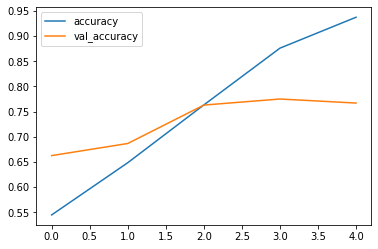

In [ ]:
#Plot these metrics value accuracy and accuracy

plt.plot(history.history['accuracy'], label = 'accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.legend()
plt.show()

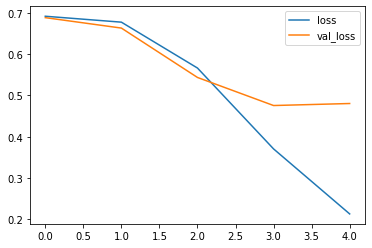

In [ ]:
#Plot these metrics value accuracy and accuracy

plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

In [ ]:
#Execute sentiment analysis model

def predict_sentiment(text):
    tw = tokenizer.texts_to_sequences([text])
    tw = pad_sequences(tw, maxlen = 200)
    prediction = int(model.predict(tw).round().item())
    print("Predicted Sentiment: ", sentiment_label[1][prediction])

#using these two sentences to execute the model

test1 = "I liked the service provided by the airline."
predict_sentiment(test1)

test2 = "I got the worst service!"
predict_sentiment(test2)

Predicted Sentiment:  Positive
Predicted Sentiment:  Positive
